## 0. Data preparation

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import math

In [2]:
pfas = pd.read_csv('PFAS_data_130.csv')
pfas.head()

,Log Files,Molecule,SMILES,a0,a1,a2,a3,a4,H_f_0K,S(300K),...,F-C-C-C Torsions,F-C-C-F Torsions,F-C-C-O Torsions,F-C-O-C Torsions,O-C-C-C Torsions,O-C-C-F Torsions,O-C-C-O Torsions,O-C-O-C Torsions,O-O-C-C Torsions,O-O-C-F Torsions
0,butene.log,1C4F8,C(=C(F)C(C(F)(F)F)(F)F)(F)F,8.2447,0.13653,-0.000133,6.050000e-08,-1.040000e-11,-371.81,104.398839,...,1.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,butene_OH.log,1C4F8_OH,FC(O)(F)[C](C(F)(F)C(F)(F)F)F,8.9590,0.16092,-0.000159,7.290000e-08,-1.260000e-11,-419.97,44.901000,...,3.0,10.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,pentene.log,1C5F10,C(=C(F)C(C(F)(F)C(F)(F)F)(F)F)(F)F,10.0620,0.17448,-0.000171,7.770000e-08,-1.330000e-11,-470.07,119.440000,...,3.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,hexene.log,1C6F12,C(F)(F)(C(=C(F)F)F)C(C(C(F)(F)F)(F)F)(F)F,11.8020,0.21282,-0.000209,9.510000e-08,-1.630000e-11,-567.50,134.200000,...,5.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,heptene.log,1C7F14,C(F)(F)(C(=C(F)F)F)C(C(C(C(F)(F)F)(F)F)(F)F)(F)F,13.3720,0.25169,-0.000248,1.130000e-07,-1.940000e-11,-665.26,147.340000,...,7.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
X = pfas[pfas.columns[10:]]
X

,sp2 Pair Count C-C,sp2 Pair Count C-O,sp2 Pair Count O-O,sp2 Total Count,sp3 Pair Count C-C,sp3 Pair Count C-F,sp3 Pair Count C-O,sp3 Pair Count O-O,sp3 Total Count,Num. Atoms C,...,F-C-C-C Torsions,F-C-C-F Torsions,F-C-C-O Torsions,F-C-O-C Torsions,O-C-C-C Torsions,O-C-C-F Torsions,O-C-C-O Torsions,O-C-O-C Torsions,O-O-C-C Torsions,O-O-C-F Torsions
0,1.0,0.0,0.0,1.0,2.0,8.0,0.0,0.0,10.0,4.0,...,1.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,3.0,8.0,1.0,0.0,12.0,4.0,...,3.0,10.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,1.0,3.0,10.0,0.0,0.0,13.0,5.0,...,3.0,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,1.0,4.0,12.0,0.0,0.0,16.0,6.0,...,5.0,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,1.0,5.0,14.0,0.0,0.0,19.0,7.0,...,7.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,0.0,0.0,0.0,0.0,3.0,9.0,0.0,0.0,12.0,4.0,...,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
126,0.0,0.0,0.0,0.0,4.0,11.0,0.0,0.0,15.0,5.0,...,3.0,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
127,0.0,0.0,0.0,0.0,5.0,13.0,0.0,0.0,18.0,6.0,...,5.0,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
128,0.0,0.0,0.0,0.0,6.0,15.0,0.0,0.0,21.0,7.0,...,7.0,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
Y = pfas[pfas.columns[3]]
Y

0       8.2447
1       8.9590
2      10.0620
3      11.8020
4      13.3720
        ...   
125     6.6609
126    10.6230
127    12.3140
128    14.1180
129    15.7140
Name: a0, Length: 130, dtype: float64

In [5]:
XY = pd.concat([X,Y], axis = 1)
XY

,sp2 Pair Count C-C,sp2 Pair Count C-O,sp2 Pair Count O-O,sp2 Total Count,sp3 Pair Count C-C,sp3 Pair Count C-F,sp3 Pair Count C-O,sp3 Pair Count O-O,sp3 Total Count,Num. Atoms C,...,F-C-C-F Torsions,F-C-C-O Torsions,F-C-O-C Torsions,O-C-C-C Torsions,O-C-C-F Torsions,O-C-C-O Torsions,O-C-O-C Torsions,O-O-C-C Torsions,O-O-C-F Torsions,a0
0,1.0,0.0,0.0,1.0,2.0,8.0,0.0,0.0,10.0,4.0,...,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.2447
1,0.0,0.0,0.0,0.0,3.0,8.0,1.0,0.0,12.0,4.0,...,10.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,8.9590
2,1.0,0.0,0.0,1.0,3.0,10.0,0.0,0.0,13.0,5.0,...,12.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0620
3,1.0,0.0,0.0,1.0,4.0,12.0,0.0,0.0,16.0,6.0,...,16.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.8020
4,1.0,0.0,0.0,1.0,5.0,14.0,0.0,0.0,19.0,7.0,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.3720
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,0.0,0.0,0.0,0.0,3.0,9.0,0.0,0.0,12.0,4.0,...,11.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.6609
126,0.0,0.0,0.0,0.0,4.0,11.0,0.0,0.0,15.0,5.0,...,15.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.6230
127,0.0,0.0,0.0,0.0,5.0,13.0,0.0,0.0,18.0,6.0,...,19.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,12.3140
128,0.0,0.0,0.0,0.0,6.0,15.0,0.0,0.0,21.0,7.0,...,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,14.1180


## 1. Feature selection with correlation matrix

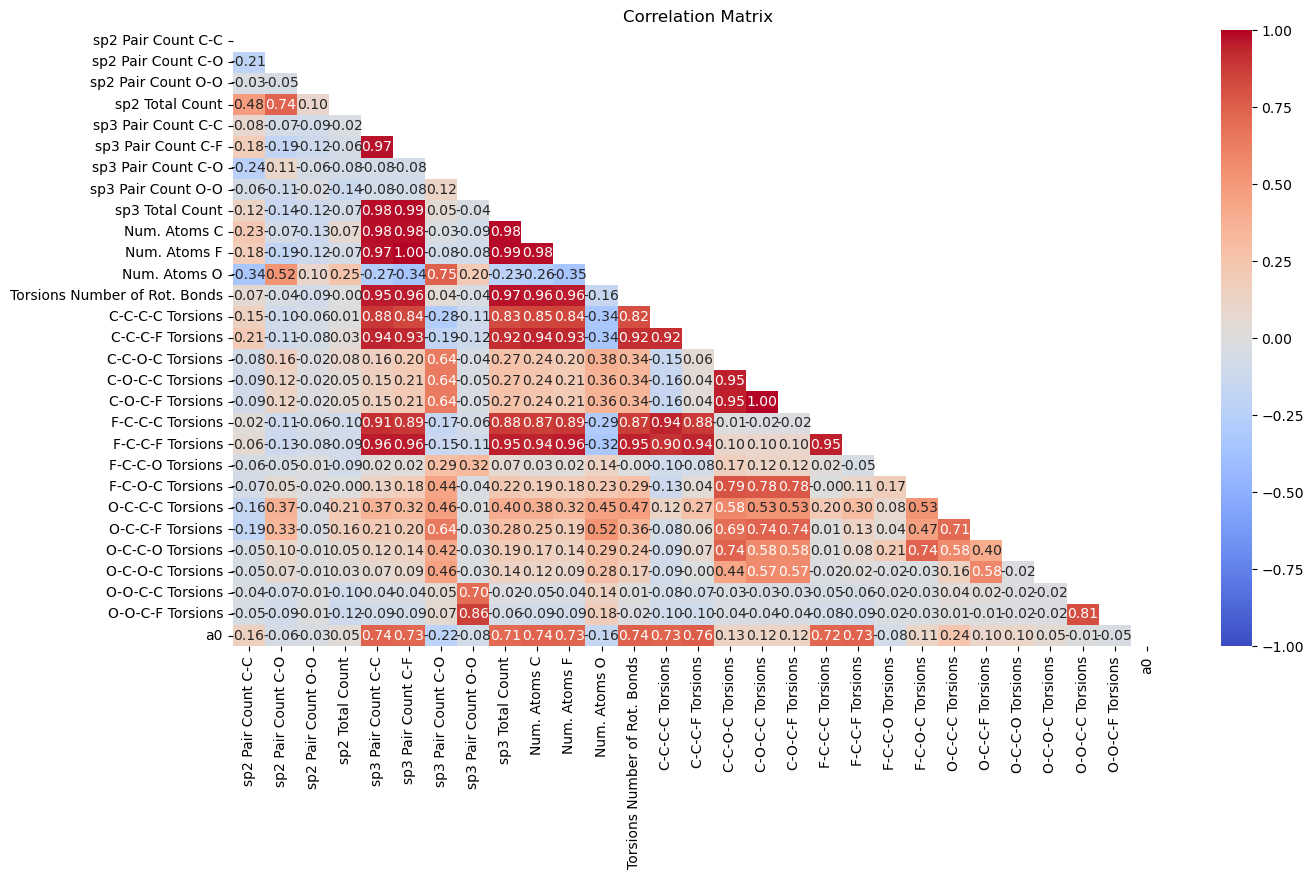

In [6]:
XY_corr = XY.corr(method='pearson')
plt.figure(figsize=(15,8))
mask = np.triu(np.ones_like(XY_corr, dtype=bool))
sns.heatmap(XY_corr, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

In [7]:
n_descps = len(X.columns) - 1
high_threshold = 0.9
low_threshold = 0.01

# excluding low correlation with a0
for descr in X.columns:
    res_y = stats.linregress(Y, X[descr])
    rsquared_y = res_y.rvalue**2
    if rsquared_y < low_threshold:
        print(f"{descr} has low correlation with a0, removing it")
        X.drop(columns=[descr], inplace = True)
        n_descps -= 1

# detecting descriptors that are strongly correlated with each other
descp_drop = set()
cols = list(X.columns)

for i, col1 in enumerate(cols):
    if col1 in descp_drop:
        continue  # skip if already removed

    for j in range(i + 1, len(cols)):
        col2 = cols[j]
        if col2 in descp_drop:
            continue  # skip if already removed

        res_x = stats.linregress(X[col2], X[col1])
        rsquared = res_x.rvalue**2

        if rsquared > high_threshold:
            print(f"{col1} has high correlation with {col2}")
            
            # Check which one is more strongly correlated with the target
            res_iy = stats.linregress(Y, X[col2])
            rsquared_iy = res_iy.rvalue**2
            res_jy = stats.linregress(Y, X[col1])
            rsquared_jy = res_jy.rvalue**2

            if rsquared_iy > rsquared_jy:
                print(f"--> Removing {col2}")
                descp_drop.add(col2)
            else:
                print(f"--> Removing {col1}")
                descp_drop.add(col1)
                break  # Stop checking col1 if it's removed

# drop descriptors
print("Dropping descriptors:", descp_drop)
X.drop(columns=descp_drop, inplace=True)
n_descps = len(X.columns) - 1
print(f"Number of descriptors after filtering: {n_descps}")
X.head()

sp2 Pair Count C-O has low correlation with a0, removing it
sp2 Pair Count O-O has low correlation with a0, removing it
sp2 Total Count has low correlation with a0, removing it
sp3 Pair Count O-O has low correlation with a0, removing it
F-C-C-O Torsions has low correlation with a0, removing it
O-C-C-F Torsions has low correlation with a0, removing it
O-C-O-C Torsions has low correlation with a0, removing it
O-O-C-C Torsions has low correlation with a0, removing it
O-O-C-F Torsions has low correlation with a0, removing it
sp3 Pair Count C-C has high correlation with sp3 Pair Count C-F
--> Removing sp3 Pair Count C-C
sp3 Pair Count C-F has high correlation with sp3 Total Count
--> Removing sp3 Pair Count C-F
sp3 Total Count has high correlation with Num. Atoms C
--> Removing Num. Atoms C
sp3 Total Count has high correlation with Num. Atoms F
--> Removing Num. Atoms F
sp3 Total Count has high correlation with Torsions Number of Rot. Bonds
--> Removing Torsions Number of Rot. Bonds
C-O-C-C

/tmp/ipykernel_1164546/1005772786.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop(columns=[descr], inplace = True)
/tmp/ipykernel_1164546/1005772786.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop(columns=[descr], inplace = True)
/tmp/ipykernel_1164546/1005772786.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.drop(columns=[descr], inplace = True)
/tmp/ipykernel_1164546/1005772786.py:11: SettingWithCopyWa

,sp2 Pair Count C-C,sp3 Pair Count C-O,sp3 Total Count,Num. Atoms O,C-C-C-C Torsions,C-C-C-F Torsions,C-C-O-C Torsions,C-O-C-F Torsions,F-C-C-C Torsions,F-C-O-C Torsions,O-C-C-C Torsions,O-C-C-O Torsions
0,1.0,0.0,10.0,0.0,1.0,5.0,0.0,0.0,1.0,0.0,0.0,0.0
1,0.0,1.0,12.0,1.0,1.0,5.0,0.0,0.0,3.0,0.0,1.0,0.0
2,1.0,0.0,13.0,0.0,2.0,7.0,0.0,0.0,3.0,0.0,0.0,0.0
3,1.0,0.0,16.0,0.0,3.0,9.0,0.0,0.0,5.0,0.0,0.0,0.0
4,1.0,0.0,19.0,0.0,4.0,11.0,0.0,0.0,7.0,0.0,0.0,0.0


## 2. A glimpse of chemical space with UMAP and 4 different ways of scaling

In [8]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler
import umap

/home/ngohviet/.conda/envs/chem480a5/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# try 3 different ways of scaling data
X_SS = StandardScaler(with_mean=False).fit_transform(X)
X_MMS = MinMaxScaler().fit_transform(X)
X_MAS = MaxAbsScaler().fit_transform(X)

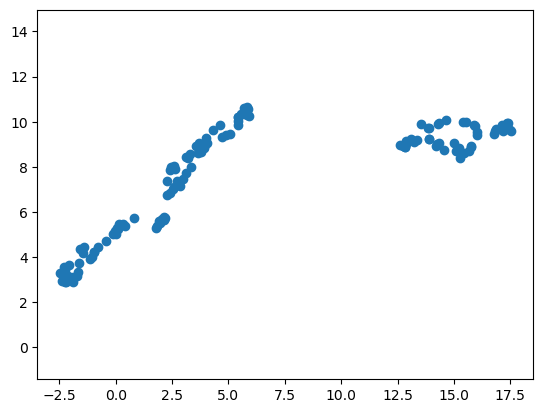

In [10]:
# UMAP for no scaling data
reducer = umap.UMAP(n_components = 2)
embedding = reducer.fit_transform(X)

plt.scatter(
    embedding[:, 0],
    embedding[:, 1])
plt.gca().set_aspect('equal', 'datalim')

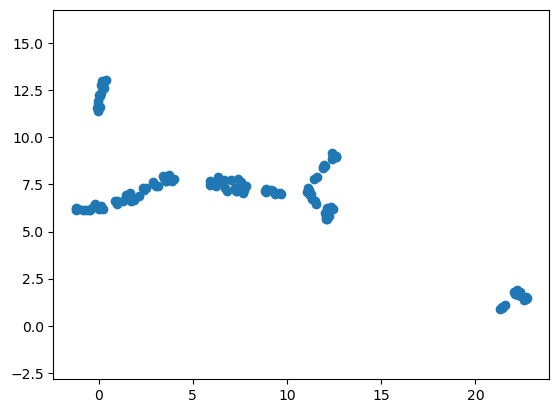

In [11]:
# UMAP for standard scaling data
reducer1 = umap.UMAP(n_components = 2)
embedding_SS = reducer1.fit_transform(X_SS)

plt.scatter(
    embedding_SS[:, 0],
    embedding_SS[:, 1])
plt.gca().set_aspect('equal', 'datalim')

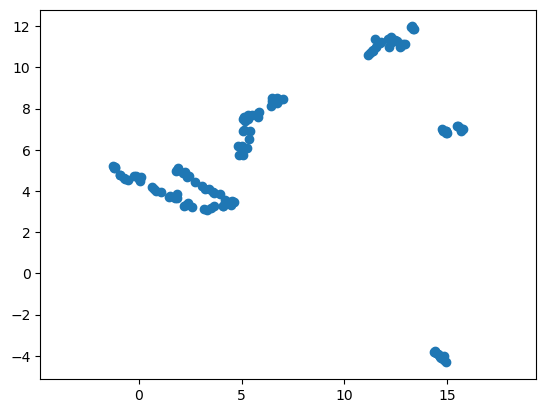

In [12]:
# UMAP for min max scaling data
reducer2 = umap.UMAP(n_components = 2)
embedding_MMS = reducer2.fit_transform(X_MMS)

plt.scatter(
    embedding_MMS[:, 0],
    embedding_MMS[:, 1])
plt.gca().set_aspect('equal', 'datalim')

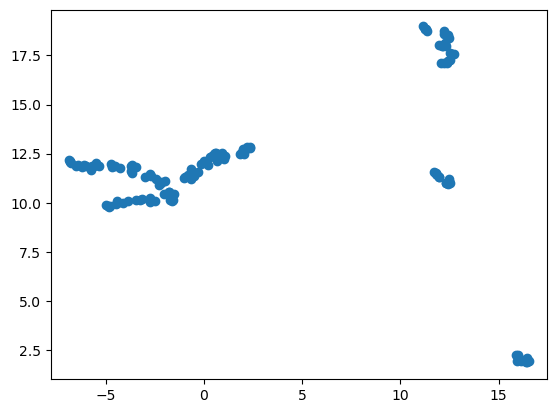

In [13]:
# UMAP for max abs scaling data
reducer3 = umap.UMAP(n_components = 2)
embedding_MAS = reducer3.fit_transform(X_MAS)

plt.scatter(
    embedding_MAS[:, 0],
    embedding_MAS[:, 1])
plt.gca().set_aspect('equal', 'datalim')

**We can see that data forms different clusters, so random split might not be a good idea, but I haven't figured out how to access to each cluster to split them yet.**

## 3. Predicting a0 with Standard Scaling data, random split and some simple models

In [14]:
from sklearn.model_selection import train_test_split, cross_validate, RepeatedKFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
from sklearn.neural_network import MLPRegressor
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn_evaluation import plot
from sklearn.inspection import permutation_importance

In [15]:
# Fit model and compute regression scores (R2), including CV:
def report_regression_scores(model, X_train, y_train, X_test, y_test, X, y, cv):
    # fit & predict
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_train_pred = model.predict(X_train)

    # --- holdout (train/test split) metrics ---
    train_r2   = metrics.r2_score(y_train, y_train_pred)
    test_r2    = metrics.r2_score(y_test, y_pred)

    # --- cross-validation metrics ---
    scores = cross_validate(
        model, X, y,
        cv=cv,                    
        return_train_score=True,
        scoring='r2',
    )
    scores_table = pd.DataFrame(scores)

    train_cv_scores = np.round(scores_table["train_score"].values, 3)
    test_cv_scores  = np.round(scores_table["test_score"].values, 3)

    # Build & return a summary table
    summary_df = pd.DataFrame({
        "Train R2":   [round(train_r2,3)],
        "Test R2":    [round(test_r2,3)],
        "Train CV Scores": [train_cv_scores],
        "Test CV Scores": [test_cv_scores],
    }, index=[model.__class__.__name__])

    return summary_df

In [16]:
# Print permutation feature importance
def print_permutation_importance(model, X_train, y_train, X_test, y_test, feature_names, n_repeats=30, random_state=15):
    
    model.fit(X_train, y_train)
    r = permutation_importance(model, X_test, y_test, n_repeats=n_repeats, random_state=random_state)

    print(f"\nPermutation importances for {model.__class__.__name__}:")
    print(f"{'Feature':<20} Mean ± Std")
    for idx in r.importances_mean.argsort()[::-1]:
        mean, std = r.importances_mean[idx], r.importances_std[idx]
        if mean - 2*std > 0:
            print(f"{feature_names[idx]:<20} {mean:.3f} ± {std:.3f}")
    return r

In [17]:
# Plot permutation feature importance
def plot_permutation_importance(models, X_train, y_train, X_test, y_test, feature_names, cols, n_features, n_repeats=30, random_state=15):
    # create subplots
    n = len(models)
    rows = math.ceil(n/cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*4))
    if n == 1:
        axes = [axes]    
    axes = axes.flatten()

    # fit model and plot permutation feature importance 
    for ax, model in zip(axes, models):
        model.fit(X_train, y_train)
        r = permutation_importance(model, X_test, y_test, n_repeats=n_repeats, random_state=random_state)
        idxs = r.importances_mean.argsort()[::-1]

        ax.barh(range(len(idxs)), r.importances_mean[idxs], xerr=r.importances_std[idxs], align='center')
        ax.set_yticks(range(len(idxs)))
        ax.set_yticklabels([feature_names[i] for i in idxs])
        ax.invert_yaxis()
        ax.set_title(f"{model.__class__.__name__}")
        ax.set_xlabel("Permutation Importance")

    for empty_ax in axes[len(models):]:
        empty_ax.set_visible(False)
    
    plt.tight_layout()
    plt.savefig(f"PFI_{n_features}features.png",        
            dpi=300,
            bbox_inches='tight')
    plt.show()

In [52]:
# list out all the models I wanna try
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))

models = [Ridge(alpha=0.5, random_state=42), 
          Lasso(alpha=0.01, random_state=42),
          ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
          SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale'),
          KNeighborsRegressor(n_neighbors=11, weights="distance", metric="minkowski",p=1),
          GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42),
          RandomForestRegressor(n_estimators=500, max_depth=None, min_samples_leaf=2, random_state=42),
          DecisionTreeRegressor(random_state=42),
          GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5, alpha=1e-8, random_state=42),
          MLPRegressor(
              hidden_layer_sizes=(32,16),
              activation="relu",
              solver="adam",
              alpha=1e-3,
              learning_rate_init=1e-3,
              max_iter=5000,
              early_stopping=True,
              validation_fraction=0.2,
              n_iter_no_change=30,
              random_state=1)]

### Try different train/test split ratio

**Train/Test = 90:10**

In [53]:
X_train, X_test, y_train, y_test = train_test_split(X_SS, Y, test_size=0.1, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_SS, Y, cv=10)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.738,0.526,"[0.717, 0.732, 0.746, 0.688, 0.788, 0.773, 0.7...","[0.813, 0.503, 0.456, 0.428, 0.231, 0.367, -1...."
Lasso,0.737,0.526,"[0.717, 0.732, 0.746, 0.687, 0.787, 0.773, 0.7...","[0.827, 0.494, 0.445, 0.416, 0.221, 0.362, -1...."
ElasticNet,0.737,0.523,"[0.716, 0.732, 0.746, 0.687, 0.787, 0.773, 0.7...","[0.83, 0.507, 0.461, 0.428, 0.218, 0.358, -1.7..."
SVR,0.719,0.423,"[0.698, 0.713, 0.732, 0.682, 0.793, 0.77, 0.78...","[0.884, 0.264, 0.57, 0.572, -0.133, 0.21, -0.7..."
KNeighborsRegressor,0.940,0.674,"[0.939, 0.941, 0.944, 0.94, 0.975, 0.975, 0.93...","[0.911, 0.494, 0.668, 0.457, -0.336, 0.367, -2..."
GradientBoostingRegressor,0.907,0.556,"[0.905, 0.916, 0.914, 0.917, 0.962, 0.939, 0.9...","[0.908, -0.199, -0.191, 0.524, -0.329, 0.412, ..."
RandomForestRegressor,0.834,0.599,"[0.831, 0.846, 0.849, 0.817, 0.899, 0.848, 0.8...","[0.895, -0.059, 0.069, 0.546, 0.083, 0.337, -8..."
DecisionTreeRegressor,0.940,0.463,"[0.939, 0.941, 0.944, 0.94, 0.975, 0.975, 0.93...","[0.758, -1.635, -0.119, 0.436, -0.16, 0.409, -..."
GaussianProcessRegressor,0.742,0.527,"[0.732, 0.747, 0.754, 0.698, 0.796, 0.783, 0.7...","[0.91, 0.494, 0.555, 0.583, 0.15, 0.324, -1.68..."
MLPRegressor,0.709,0.461,"[0.709, 0.728, 0.741, 0.693, 0.792, 0.784, 0.7...","[0.754, 0.513, 0.56, 0.451, 0.362, 0.389, -1.6..."


Clearly overfit: Test R2 < Train R2, and cross-validation (CV) R2 values vary by a lot.

**Train/Test = 83.3:16.7**

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X_SS, Y, test_size=0.167, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_SS, Y, cv=6)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.730,0.654,"[0.705, 0.751, 0.748, 0.789, 0.741, 0.715]","[0.903, 0.572, 0.601, 0.258, -1.069, 0.82]"
Lasso,0.730,0.704,"[0.705, 0.751, 0.747, 0.788, 0.741, 0.715]","[0.908, 0.571, 0.594, 0.257, -1.059, 0.805]"
ElasticNet,0.730,0.700,"[0.705, 0.751, 0.747, 0.788, 0.741, 0.714]","[0.91, 0.576, 0.593, 0.255, -1.045, 0.816]"
SVR,0.711,0.684,"[0.682, 0.736, 0.757, 0.797, 0.756, 0.715]","[0.875, 0.565, 0.441, 0.292, 0.805, 0.828]"
KNeighborsRegressor,0.937,0.831,"[0.937, 0.946, 0.976, 0.975, 0.944, 0.936]","[0.936, 0.665, 0.312, 0.173, 0.414, 0.829]"
GradientBoostingRegressor,0.911,0.749,"[0.904, 0.932, 0.963, 0.957, 0.909, 0.915]","[0.925, 0.387, 0.306, 0.339, -0.232, 0.864]"
RandomForestRegressor,0.819,0.756,"[0.821, 0.852, 0.884, 0.869, 0.828, 0.83]","[0.941, 0.337, 0.528, -0.201, 0.55, 0.845]"
DecisionTreeRegressor,0.937,0.688,"[0.937, 0.946, 0.976, 0.975, 0.944, 0.936]","[0.744, 0.389, 0.092, -1.219, 0.563, 0.856]"
GaussianProcessRegressor,0.733,0.720,"[0.722, 0.759, 0.755, 0.807, 0.747, 0.737]","[0.929, 0.63, 0.562, 0.253, -0.06, 0.835]"
MLPRegressor,0.714,0.614,"[0.612, 0.647, 0.731, 0.79, 0.735, 0.708]","[0.864, 0.605, 0.644, 0.231, 0.439, 0.816]"


Less overfit except GBR, RFR, DTR and kNN but the cross-validation (CV) values still vary a lot. --> Should be because of random split.

**Train/Test = 80/20**

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.717,0.749,"[0.714, 0.699, 0.892, 0.782, 0.713]","[0.76, 0.772, -0.06, -1.719, 0.559]"
Lasso,0.717,0.779,"[0.714, 0.699, 0.891, 0.782, 0.713]","[0.797, 0.775, -0.051, -1.734, 0.579]"
ElasticNet,0.717,0.777,"[0.713, 0.699, 0.891, 0.782, 0.713]","[0.79, 0.776, -0.056, -1.693, 0.586]"
SVR,0.697,0.766,"[0.684, 0.681, 0.9, 0.812, 0.702]","[0.758, 0.71, -0.058, 0.18, 0.796]"
KNeighborsRegressor,0.938,0.844,"[0.936, 0.941, 0.97, 0.94, 0.934]","[0.85, 0.856, -0.135, -0.613, 0.843]"
GradientBoostingRegressor,0.912,0.791,"[0.906, 0.905, 0.965, 0.918, 0.906]","[0.776, 0.691, -0.229, -4.593, 0.781]"
RandomForestRegressor,0.815,0.807,"[0.838, 0.822, 0.932, 0.867, 0.824]","[0.77, 0.695, -0.068, -2.59, 0.858]"
DecisionTreeRegressor,0.938,0.749,"[0.936, 0.941, 0.97, 0.94, 0.934]","[0.432, 0.657, -0.106, -5.43, 0.836]"
GaussianProcessRegressor,0.718,0.791,"[0.729, 0.704, 0.896, 0.805, 0.729]","[0.864, 0.819, -0.043, -0.367, 0.822]"
MLPRegressor,0.714,0.768,"[0.722, 0.708, 0.873, 0.807, 0.717]","[0.82, 0.793, 0.177, -0.359, 0.682]"


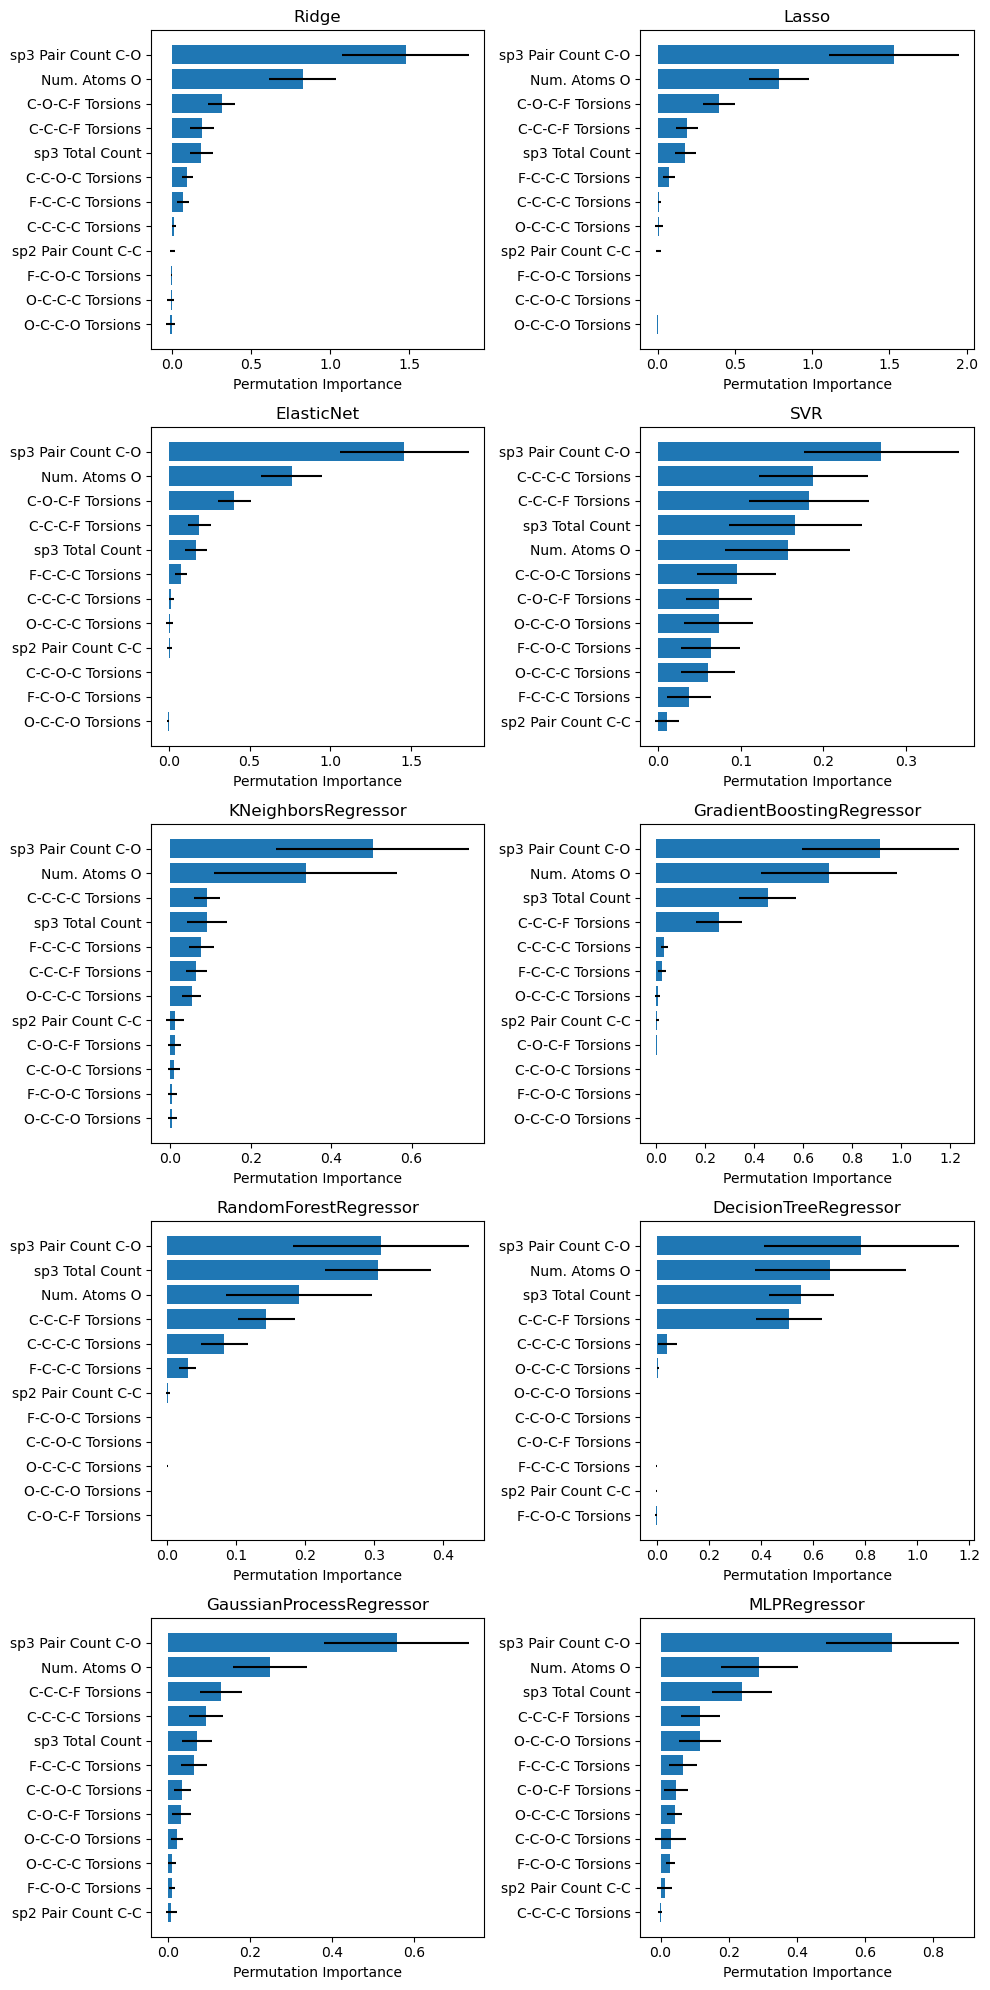

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X_SS, Y, test_size=0.2, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_SS, Y, cv=5)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

# big subplot of permutation feature importance
plot_permutation_importance(models, X_train, y_train, X_test, y_test, list(X.columns), cols=2, n_features=11)

* Much less overfitting except GBR, RFR, DTR, kNN but the cross-validation problem doesn't change.
* Only 6-7 descriptors are meaningful for most of the models, except SVR --> Need more descriptors.

**Train/Test = 75:25**

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.704,0.776,"[0.722, 0.74, 0.805, 0.72]","[0.691, 0.606, 0.333, 0.253]"
Lasso,0.704,0.803,"[0.722, 0.74, 0.805, 0.719]","[0.713, 0.599, 0.33, 0.181]"
ElasticNet,0.704,0.801,"[0.722, 0.74, 0.805, 0.719]","[0.714, 0.599, 0.333, 0.331]"
SVR,0.681,0.799,"[0.679, 0.749, 0.821, 0.713]","[0.723, 0.449, 0.375, 0.808]"
KNeighborsRegressor,0.940,0.841,"[0.934, 0.984, 0.977, 0.936]","[0.809, 0.341, 0.179, 0.781]"
GradientBoostingRegressor,0.919,0.812,"[0.914, 0.971, 0.967, 0.915]","[0.688, 0.366, -0.513, 0.813]"
RandomForestRegressor,0.803,0.786,"[0.834, 0.883, 0.882, 0.814]","[0.706, 0.544, -0.271, 0.809]"
DecisionTreeRegressor,0.940,0.687,"[0.934, 0.984, 0.977, 0.936]","[0.501, 0.139, -1.051, 0.846]"
GaussianProcessRegressor,0.703,0.818,"[0.734, 0.743, 0.823, 0.738]","[0.795, 0.566, 0.331, 0.762]"
MLPRegressor,0.495,0.576,"[0.736, 0.751, 0.813, 0.732]","[0.694, 0.632, 0.353, 0.503]"


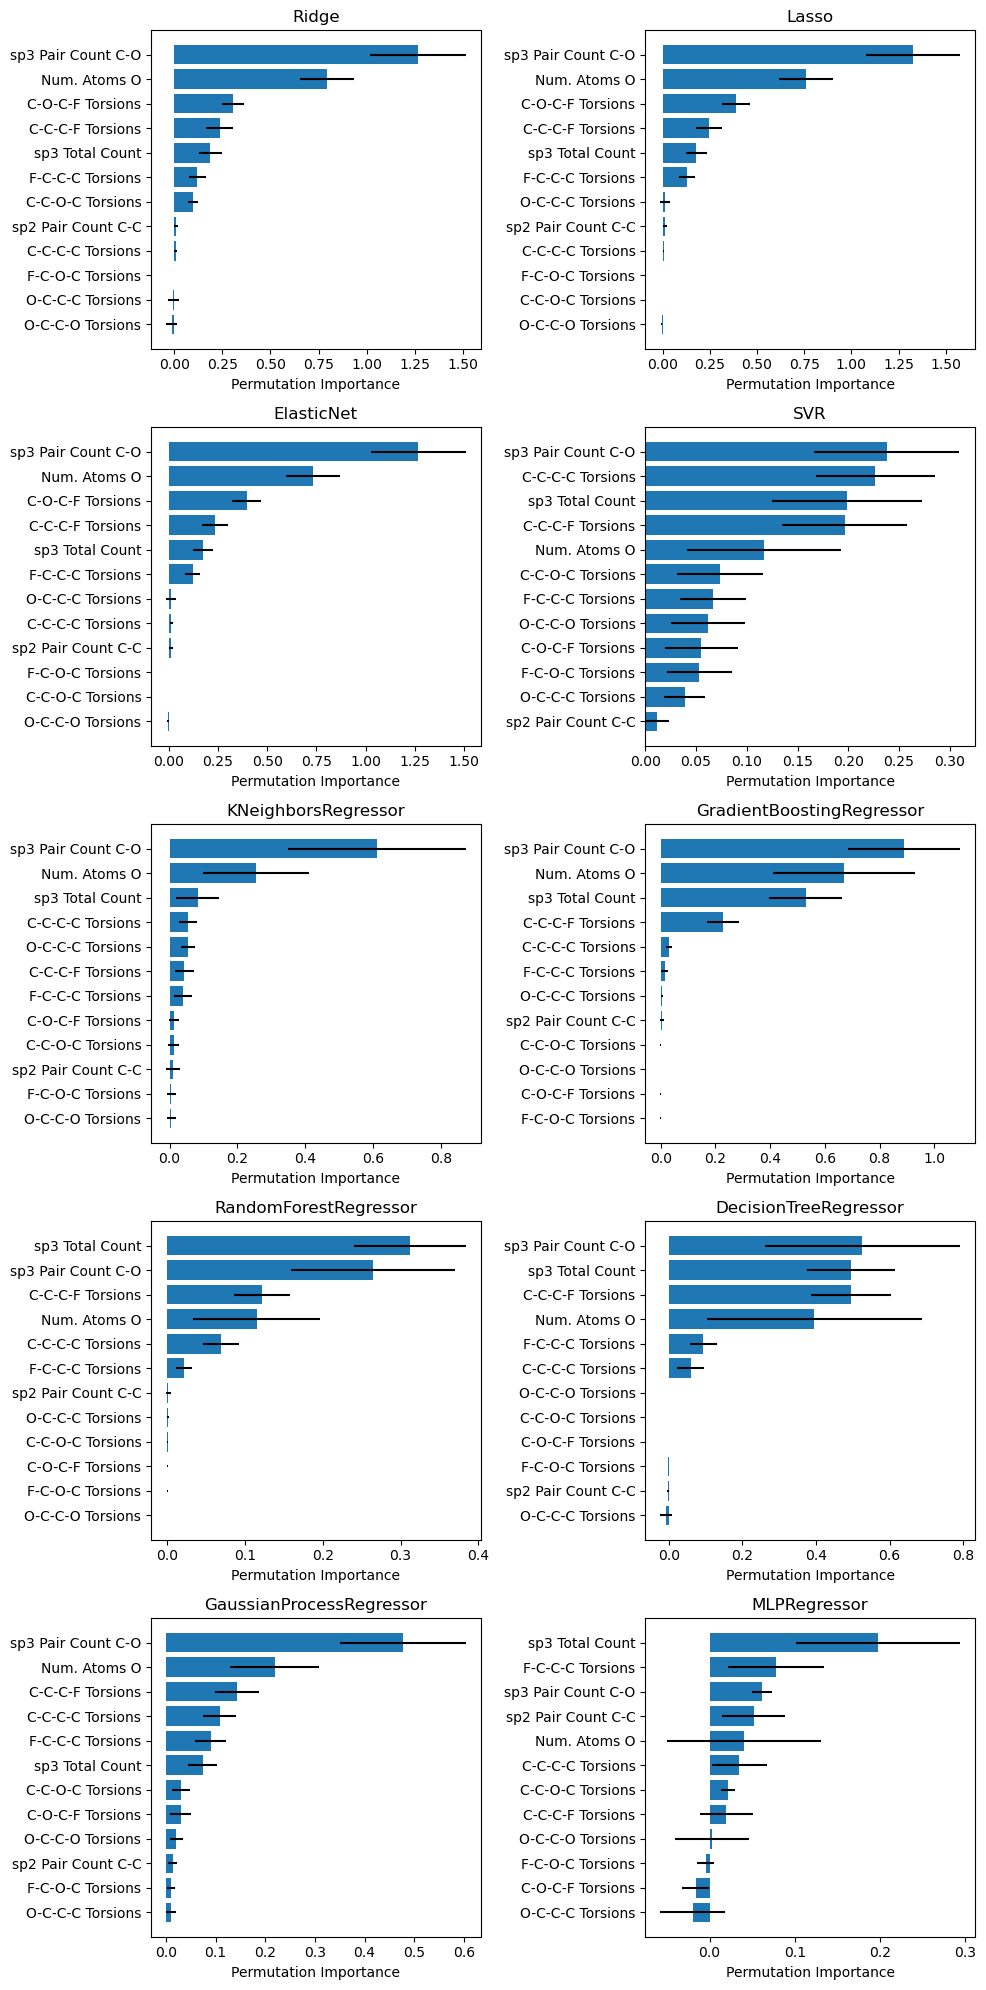

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X_SS, Y, test_size=0.25, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_SS, Y, cv=4)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

# big subplot of permutation feature importance
plot_permutation_importance(models, X_train, y_train, X_test, y_test, list(X.columns), cols=2, n_features=11)

* Similarly, the overfitting problem is much less except for GBR, RFR, DTR, and kNN.
* Although the CV scores of the test set still vary a lot, it is less than all other train/test split ratios.
* The only neural network model (MLPRegressor) performance decreases drastically, but we may fix that by tuning the hyperparameters of the model.
* I personally prefer this ratio.
* Similarly, only 6-7 descriptors matter, except SVR.

**Train/Test = 66.7:33.3**

In [57]:
# Try 66.7/33.3 train/test split 
X_train, X_test, y_train, y_test = train_test_split(X_SS, Y, test_size=0.333, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_SS, Y, cv=3)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.736,0.709,"[0.721, 0.872, 0.749]","[0.706, 0.457, -0.119]"
Lasso,0.736,0.718,"[0.721, 0.872, 0.749]","[0.722, 0.448, -0.13]"
ElasticNet,0.736,0.717,"[0.72, 0.872, 0.749]","[0.721, 0.452, -0.112]"
SVR,0.727,0.630,"[0.672, 0.881, 0.771]","[0.731, 0.493, 0.658]"
KNeighborsRegressor,0.983,0.616,"[0.938, 0.97, 0.935]","[0.814, 0.434, 0.475]"
GradientBoostingRegressor,0.951,0.557,"[0.928, 0.966, 0.923]","[0.658, 0.358, 0.176]"
RandomForestRegressor,0.842,0.528,"[0.832, 0.914, 0.837]","[0.674, 0.441, 0.563]"
DecisionTreeRegressor,0.983,0.221,"[0.938, 0.97, 0.935]","[0.527, 0.345, 0.368]"
GaussianProcessRegressor,0.745,0.682,"[0.728, 0.875, 0.754]","[0.8, 0.455, 0.305]"
MLPRegressor,0.708,0.617,"[0.739, 0.845, 0.773]","[0.715, 0.495, 0.406]"


Slightly overfitting.

**Train/Test = 50:50**

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X_SS, Y, test_size=0.5, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_SS, Y, cv=2)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.796,0.659,"[0.721, 0.813]","[0.639, 0.206]"
Lasso,0.796,0.659,"[0.721, 0.814]","[0.636, 0.19]"
ElasticNet,0.796,0.659,"[0.721, 0.814]","[0.64, 0.201]"
SVR,0.824,0.556,"[0.718, 0.826]","[0.513, 0.606]"
KNeighborsRegressor,0.982,0.487,"[0.983, 0.973]","[0.483, 0.411]"
GradientBoostingRegressor,0.969,0.334,"[0.979, 0.97]","[0.36, -0.338]"
RandomForestRegressor,0.868,0.461,"[0.891, 0.886]","[0.564, 0.198]"
DecisionTreeRegressor,0.982,0.072,"[0.983, 0.973]","[0.192, -0.429]"
GaussianProcessRegressor,0.826,0.594,"[0.72, 0.83]","[0.639, 0.491]"
MLPRegressor,0.759,0.582,"[0.717, 0.81]","[0.65, 0.464]"


Clearly overfitting.

### Overall conclusion:
- GBR, RFR, and DTR are clearly overfitting across different train/test splitting ratios. They're also the models that are independent of scaling data. We can exclude them now.
- 75:25 train/test split ratio gives the best results.
- The maximum performance for now is 77-78%, which is decent because we haven't optimized everything yet.
- Cross-validation scores are bad across all cases, showing that the problem lies somewhere else. That could be the random splitting. I'll try to find a way to access these clusters and split them.
- Permutation feature importance shows that there are only 6-7 descriptors that matter. We might need more descriptors. I wonder if descriptors involving S atoms are missing here.

## 4. Try fitting data with Max Abs Scaling

In [59]:
# list out all the models I wanna try
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2)) + WhiteKernel(noise_level=1e-3, noise_level_bounds=(1e-8, 1e1))

models = [Ridge(alpha=0.5, random_state=42), 
          Lasso(alpha=0.01, random_state=42),
          ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42),
          SVR(kernel='rbf', C=10, epsilon=0.1, gamma='scale'),
          KNeighborsRegressor(n_neighbors=11, weights="distance", metric="minkowski",p=1),
          GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=5, alpha=1e-8, random_state=42),
          MLPRegressor(
              hidden_layer_sizes=(32,16),
              activation="relu",
              solver="adam",
              alpha=1e-3,
              learning_rate_init=1e-3,
              max_iter=5000,
              early_stopping=True,
              validation_fraction=0.2,
              n_iter_no_change=30,
              random_state=1)]

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X_MAS, Y, test_size=0.1, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_MAS, Y, cv=10)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.722,0.456,"[0.7, 0.716, 0.729, 0.67, 0.78, 0.762, 0.745, ...","[0.932, 0.532, 0.539, 0.47, 0.097, 0.263, -1.2..."
Lasso,0.732,0.504,"[0.712, 0.728, 0.742, 0.682, 0.783, 0.768, 0.7...","[0.915, 0.481, 0.467, 0.369, 0.156, 0.311, -1...."
ElasticNet,0.714,0.417,"[0.691, 0.708, 0.721, 0.66, 0.775, 0.755, 0.73...","[0.957, 0.517, 0.54, 0.455, 0.054, 0.227, -1.1..."
SVR,0.721,0.385,"[0.704, 0.719, 0.729, 0.681, 0.794, 0.774, 0.7...","[0.909, 0.314, 0.536, 0.582, -0.172, 0.196, -1..."
KNeighborsRegressor,0.940,0.655,"[0.939, 0.941, 0.944, 0.94, 0.975, 0.975, 0.93...","[0.944, 0.369, 0.7, 0.527, -0.331, 0.372, -2.5..."
GaussianProcessRegressor,0.741,0.520,"[0.729, 0.745, 0.753, 0.696, 0.795, 0.783, 0.7...","[0.907, 0.509, 0.551, 0.575, 0.137, 0.317, -1...."
MLPRegressor,0.611,0.070,"[0.652, 0.663, 0.672, 0.63, 0.77, 0.801, 0.756...","[0.918, 0.465, 0.503, 0.528, 0.021, 0.413, -1...."


In [64]:
X_train, X_test, y_train, y_test = train_test_split(X_MAS, Y, test_size=0.167, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_MAS, Y, cv=6)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.713,0.678,"[0.686, 0.733, 0.738, 0.772, 0.724, 0.698]","[0.954, 0.621, 0.536, 0.199, -0.515, 0.845]"
Lasso,0.726,0.695,"[0.7, 0.747, 0.743, 0.783, 0.738, 0.712]","[0.944, 0.589, 0.568, 0.239, -0.948, 0.789]"
ElasticNet,0.707,0.661,"[0.678, 0.726, 0.733, 0.765, 0.717, 0.692]","[0.961, 0.624, 0.52, 0.184, -0.411, 0.856]"
SVR,0.713,0.670,"[0.687, 0.737, 0.76, 0.799, 0.748, 0.725]","[0.915, 0.557, 0.418, 0.278, 0.787, 0.834]"
KNeighborsRegressor,0.937,0.817,"[0.937, 0.946, 0.976, 0.975, 0.944, 0.936]","[0.948, 0.637, 0.323, 0.16, 0.33, 0.842]"
GaussianProcessRegressor,0.732,0.717,"[0.717, 0.758, 0.754, 0.805, 0.746, 0.734]","[0.944, 0.626, 0.556, 0.245, -0.236, 0.851]"
MLPRegressor,0.685,0.613,"[0.574, 0.619, 0.731, 0.787, 0.762, 0.77]","[0.936, 0.567, 0.507, 0.227, -0.448, 0.824]"


In [63]:
X_train, X_test, y_train, y_test = train_test_split(X_MAS, Y, test_size=0.2, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_MAS, Y, cv=5)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.699,0.762,"[0.694, 0.677, 0.887, 0.757, 0.694]","[0.895, 0.812, -0.087, -0.922, 0.754]"
Lasso,0.713,0.774,"[0.707, 0.694, 0.888, 0.779, 0.71]","[0.854, 0.79, -0.05, -1.615, 0.702]"
ElasticNet,0.692,0.751,"[0.687, 0.669, 0.884, 0.751, 0.689]","[0.888, 0.812, -0.083, -0.827, 0.795]"
SVR,0.698,0.756,"[0.69, 0.682, 0.901, 0.815, 0.713]","[0.798, 0.705, -0.097, 0.069, 0.809]"
KNeighborsRegressor,0.938,0.838,"[0.936, 0.941, 0.97, 0.94, 0.934]","[0.849, 0.855, -0.173, -0.706, 0.855]"
GaussianProcessRegressor,0.717,0.790,"[0.726, 0.703, 0.896, 0.807, 0.725]","[0.882, 0.817, -0.059, -0.567, 0.809]"
MLPRegressor,0.711,0.780,"[0.694, 0.686, 0.884, 0.828, 0.717]","[0.866, 0.796, -0.017, -0.78, 0.769]"


In [60]:
X_train, X_test, y_train, y_test = train_test_split(X_MAS, Y, test_size=0.25, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_MAS, Y, cv=4)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.683,0.795,"[0.698, 0.728, 0.784, 0.697]","[0.825, 0.545, 0.327, 0.694]"
Lasso,0.700,0.804,"[0.716, 0.736, 0.801, 0.717]","[0.796, 0.577, 0.337, 0.613]"
ElasticNet,0.679,0.790,"[0.693, 0.725, 0.779, 0.694]","[0.821, 0.535, 0.322, 0.712]"
SVR,0.688,0.797,"[0.69, 0.752, 0.829, 0.725]","[0.755, 0.432, 0.325, 0.816]"
KNeighborsRegressor,0.940,0.836,"[0.934, 0.984, 0.977, 0.936]","[0.813, 0.348, 0.171, 0.797]"
GaussianProcessRegressor,0.702,0.816,"[0.733, 0.742, 0.826, 0.733]","[0.812, 0.562, 0.311, 0.764]"
MLPRegressor,0.597,0.674,"[0.723, 0.764, 0.806, 0.722]","[0.693, 0.605, 0.311, 0.492]"


In [61]:
X_train, X_test, y_train, y_test = train_test_split(X_MAS, Y, test_size=0.333, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_MAS, Y, cv=3)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.713,0.698,"[0.693, 0.865, 0.721]","[0.822, 0.429, 0.268]"
Lasso,0.732,0.716,"[0.715, 0.868, 0.747]","[0.793, 0.441, -0.074]"
ElasticNet,0.712,0.698,"[0.692, 0.864, 0.722]","[0.82, 0.432, 0.249]"
SVR,0.736,0.622,"[0.685, 0.881, 0.766]","[0.753, 0.475, 0.682]"
KNeighborsRegressor,0.983,0.618,"[0.938, 0.97, 0.935]","[0.803, 0.43, 0.504]"
GaussianProcessRegressor,0.752,0.677,"[0.726, 0.875, 0.754]","[0.813, 0.448, 0.26]"
MLPRegressor,0.681,0.643,"[0.713, 0.854, 0.543]","[0.711, 0.392, 0.691]"


In [62]:
X_train, X_test, y_train, y_test = train_test_split(X_MAS, Y, test_size=0.5, random_state=42)
# Report metrics per model
rows = []
for m in models:
    df_row = report_regression_scores(m, X_train, y_train, X_test, y_test, X_MAS, Y, cv=2)
    rows.append(df_row)
    
# concatenate all metrics into one table
all_summaries = pd.concat(rows)
display(all_summaries)

,Train R2,Test R2,Train CV Scores,Test CV Scores
Ridge,0.771,0.622,"[0.696, 0.778]","[0.632, 0.415]"
Lasso,0.792,0.650,"[0.713, 0.812]","[0.66, 0.217]"
ElasticNet,0.775,0.628,"[0.7, 0.79]","[0.639, 0.37]"
SVR,0.835,0.550,"[0.723, 0.831]","[0.515, 0.57]"
KNeighborsRegressor,0.982,0.477,"[0.983, 0.973]","[0.485, 0.401]"
GaussianProcessRegressor,0.843,0.586,"[0.713, 0.83]","[0.641, 0.461]"
MLPRegressor,0.679,0.496,"[0.701, 0.716]","[0.581, 0.536]"


### Conclusion: Doesn't change much of the result:
- Train/test split ratio: same pattern with 75/25 to be the best with the least overfitting
- The cross-validation scores of the test sets are still a problem.
- kNN clearly overfit --> Exclude.

## 5. Total conclusion

### Problems:
- R2 might not be ideal yet. (But of course, we're at the screening step)
- Overfitting: Cross-validation score differs so much!
### What can we improve?
- The way we split data:
    * Random split might not be ideal. --> Need help for UMAP visualization, then access each cluster to split.
- The models we use:
    * Fine-tuning the parameters of models. --> Need to learn.
    * Use more models --> EasyML: need to learn.
    * Neural network!!! --> need to learn.
- We need to generate more descriptors.
- We can update 200 more molecules (hopefully help with less overfitting).
### Fact check: Is it true that only neural networks can predict multiple Y values?